# P1 - Abandono de clientes de telecomunicaciones
## Problema, dataset y análisis exploratorio EDA

Proyecto final de Machine Learning

Este notebook cubre la etapa 1 del proyecto de acuerdo con la guía del curso. Se presenta la formulación del problema, la descripción del dataset y el análisis exploratorio de datos (EDA) para el caso de uso de churn de clientes de telecomunicaciones.

Dataset utilizado:
- `WA_Fn-UseC_-Telco-Customer-Churn.csv`


## 1. Descripción y motivación del problema

Las empresas de telecomunicaciones operan en mercados altamente competitivos y la retención de clientes es una prioridad estratégica. El churn (abandono del servicio) afecta directamente los ingresos, aumenta los costos de adquisición y refleja la insatisfacción o la falta de valor percibido por parte del cliente.

En este contexto, el objetivo del proyecto es comprender qué factores están asociados con la salida de clientes y preparar el terreno para un modelo predictivo que permita identificar clientes con alto riesgo de churn.

### Tarea de Machine Learning
Se trata de un problema de clasificación binaria: predecir si un cliente abandonará el servicio (`Churn = Yes`) o no (`Churn = No`) en función de variables de comportamiento, contrato, servicios contratados y perfil del cliente.

### Preguntas de investigación
1. ¿Qué características están más asociadas con la deserción?
2. ¿Existe una relación clara entre el tipo de contrato, la duración del servicio y la tasa de churn?
3. ¿Los clientes con servicios adicionales o contratos más largos presentan menor propensión a abandonar?
4. ¿Hay señales de sesgo, datos faltantes o problemas de calidad que deban tratarse antes de entrenar modelos?


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(
    style="whitegrid",
    palette="Set2",
    context="notebook",
    font_scale=0.95,
    rc={
        "figure.figsize": (7, 4),
        "figure.dpi": 120,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "legend.title_fontsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "grid.alpha": 0.25,
        "axes.axisbelow": True
    }
)

paleta = sns.color_palette("Set2")
COLORES = {"No": paleta[0], "Yes": paleta[1]}
ORDEN = ["No", "Yes"]

root = Path("..")
file_path = root / "data" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

display(df.head())

Filas: 7,043
Columnas: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Descripción del dataset

El conjunto de datos contiene información de clientes de telecomunicaciones y una variable objetivo binaria `Churn`, que indica si el cliente se retiró del servicio. El dataset incluye 7,043 clientes y 21 columnas.

### Variable objetivo
- `Churn`: `Yes` si el cliente abandonó, `No` si no lo hizo.

### Tipos de variables
| Grupo | Variables | Interpretación |
|---|---|---|
| Identificador | customerID | Identificador único del cliente |
| Objetivo | Churn | Abandono registrado: Yes / No |
| Perfil | gender, SeniorCitizen, Partner, Dependents | Género, condición de adulto mayor, pareja y dependientes |
| Permanencia | tenure | Antigüedad en meses |
| Telefonía | PhoneService, MultipleLines | Servicio telefónico y líneas múltiples |
| Internet | InternetService | DSL, fibra óptica o sin internet |
| Complementos | OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies | Servicios adicionales |
| Cuenta | Contract, PaperlessBilling, PaymentMethod | Contrato, facturación y forma de pago |
| Cargos | MonthlyCharges, TotalCharges | Cargo mensual y acumulado, en las unidades monetarias de la fuente |



No se dispone de fechas individuales de alta y baja ni de una secuencia mensual por cliente. Por ello, los grupos de antigüedad no representan un seguimiento de las mismas personas a lo largo del tiempo.



In [16]:
df.info()
print("Filas duplicadas:", df.duplicated().sum())
print("Identificadores repetidos:", df["customerID"].duplicated().sum())
print("Faltantes reconocidos inicialmente:", df.isna().sum().sum())


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 3. Calidad de los datos y tratamiento

Durante la inspección de tipos encontramos dos aspectos relevantes:

1. `TotalCharges` se interpreta como texto en lugar de numérico, lo que requiere limpieza antes de análisis.
2. `SeniorCitizen` ya tiene codificación binaria (0/1), mientras el resto de variables binarias están representadas como `Yes/No`.

Estos detalles son importantes porque afectan tanto los análisis descriptivos como el preprocesamiento posterior.


In [17]:
# Ajuste de tipos y detección de valores vacíos representados como cadenas
df['TotalCharges'] = df['TotalCharges'].replace(' ', pd.NA)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print('Valores faltantes por columna:')
print(df.isna().sum().sort_values(ascending=False))

faltantes = df[df["TotalCharges"].isna()]
display(faltantes[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]])
print("Porcentaje de clientes con cargo acumulado faltante:", round(len(faltantes) / len(df) * 100, 2))


Valores faltantes por columna:
TotalCharges        11
gender               0
SeniorCitizen        0
Partner              0
customerID           0
Dependents           0
tenure               0
MultipleLines        0
PhoneService         0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
InternetService      0
TechSupport          0
StreamingTV          0
Contract             0
StreamingMovies      0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
Churn                0
dtype: int64


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


Porcentaje de clientes con cargo acumulado faltante: 0.16


Los 11 valores faltantes de TotalCharges representan el 0.16 % de la base. Todos corresponden a clientes con tenure = 0 y Churn = No. Esto podría corresponder a clientes recién incorporados al servicio que todavía no acumulan cargos, aunque no permite confirmar que el monto correcto sea cero.

Se conservan los 7043 clientes para el EDA y no se reemplazan los cargos faltantes por cero ni por un promedio. Los análisis que requieren TotalCharges utilizan los 7032 valores disponibles, mientras que los demás pueden incluir a todos los clientes. El tratamiento de estos faltantes para el modelo se definirá en la etapa de preprocesamiento, utilizando únicamente los datos de entrenamiento para calcular cualquier valor de imputación.


In [18]:
revision = {
    "tenure: valores negativos": (df["tenure"] < 0).sum(),
    "MonthlyCharges: valores negativos": (df["MonthlyCharges"] < 0).sum(),
    "TotalCharges: valores negativos": (df["TotalCharges"] < 0).sum(),
    "tenure: valores no enteros": (
        df["tenure"].notna() & (df["tenure"] % 1 != 0)
    ).sum(),
    "SeniorCitizen: valores fuera de 0/1": (
        ~df["SeniorCitizen"].isin([0, 1])
    ).sum(),
    "Churn: valores fuera de Yes/No": (
        ~df["Churn"].isin(["Yes", "No"])
    ).sum()
}

servicios = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

sin_internet = df["InternetService"] == "No"

for columna in servicios:
    sin_complemento = df[columna] == "No internet service"
    revision[columna + ": inconsistencias"] = (
        sin_internet != sin_complemento
    ).sum()

sin_telefono = df["PhoneService"] == "No"
sin_lineas = df["MultipleLines"] == "No phone service"

revision["Telefonía: inconsistencias"] = (
    sin_telefono != sin_lineas
).sum()

tabla_revision = pd.DataFrame({
    "Comprobación": revision.keys(),
    "Casos encontrados": revision.values()
})

display(tabla_revision.set_index("Comprobación"))


,Casos encontrados
Comprobación,
tenure: valores negativos,0
MonthlyCharges: valores negativos,0
TotalCharges: valores negativos,0
tenure: valores no enteros,0
SeniorCitizen: valores fuera de 0/1,0
Churn: valores fuera de Yes/No,0
OnlineSecurity: inconsistencias,0
OnlineBackup: inconsistencias,0
DeviceProtection: inconsistencias,0


In [19]:
categoricas = [
    "customerID", "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod"
]

tabla_categorias = pd.DataFrame({
    "Tipo de dato": df[categoricas].dtypes.astype(str),
    "Categorías distintas": df[categoricas].nunique(),
    "Faltantes": df[categoricas].isna().sum(),
    "Valores observados": [
        df[columna].dropna().unique().tolist()
        for columna in categoricas
    ]
})

display(tabla_categorias)

,Tipo de dato,Categorías distintas,Faltantes,Valores observados
customerID,str,7043,0,"[7590-VHVEG, 5575-GNVDE, 3668-QPYBK, 7795-CFOC..."
gender,str,2,0,"[Female, Male]"
SeniorCitizen,int64,2,0,"[0, 1]"
Partner,str,2,0,"[Yes, No]"
Dependents,str,2,0,"[No, Yes]"
PhoneService,str,2,0,"[No, Yes]"
MultipleLines,str,3,0,"[No phone service, No, Yes]"
InternetService,str,3,0,"[DSL, Fiber optic, No]"
OnlineSecurity,str,3,0,"[No, Yes, No internet service]"
OnlineBackup,str,3,0,"[Yes, No, No internet service]"


No se encuentran filas duplicadas, IDs repetidos, valores negativos ni inconsistencias en las comprobaciones anteriores. Las categorías observadas también son coherentes con la descripción de las columnas. Estas verificaciones reducen dudas concretas, pero no garantizan que todos los registros sean correctos.

No internet service indica que no existe el servicio de internet; No indica que no se contrató un complemento. Se mantienen separados porque describen situaciones diferentes.


## 4. Distribución de la variable objetivo (`Churn`)

La variable objetivo es binaria. Antes de construir modelos, es importante estudiar su balance y verificar si hay desbalance de clases. Esto influye en la elección de métricas, el punto de corte y la validación.


,Clientes,Porcentaje
Churn,,
No,5174,73.46
Yes,1869,26.54


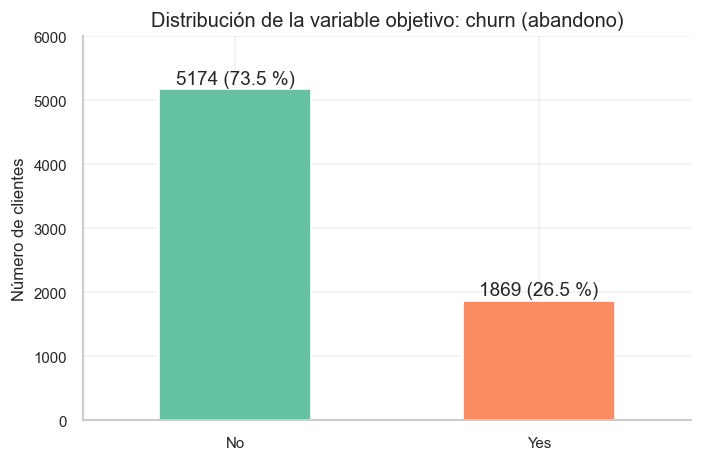

In [23]:
df["abandono"] = df["Churn"].map({"No": 0, "Yes": 1})
tasa_global = df["abandono"].mean() * 100
balance = df["Churn"].value_counts().to_frame("Clientes")
balance["Porcentaje"] = balance["Clientes"] / len(df) * 100
display(balance.round(2))

ax = balance["Clientes"].plot.bar(color=[COLORES["No"], COLORES["Yes"]],rot=0, figsize=(6, 4))
ax.set_xticklabels(["No", "Yes"])
ax.set_title("Distribución de la variable objetivo: churn (abandono)")
ax.set_xlabel("")
ax.set_ylabel("Número de clientes")
for i, cantidad in enumerate(balance["Clientes"]):
    porcentaje = balance["Porcentaje"].iloc[i]
    ax.text(i, cantidad + 80, f"{cantidad} ({porcentaje:.1f} %)", ha="center")
ax.set_ylim(0, 6000)
plt.tight_layout()
plt.show()



Hay 1869 clientes que abandonaron (26.54 %) y 5174 que no lo hicieron (73.46 %). La clase de abandono es minoritaria, aunque contiene una cantidad considerable de casos.


## 5. Estadísticas descriptivas de variables numéricas

Se analizan las variables numéricas: `tenure`, `MonthlyCharges` y `TotalCharges`. También se comparan sus distribuciones por la variable objetivo para detectar patrones de churn.


In [24]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
summary_numeric = df[numeric_cols].describe().T
summary_numeric["IQR"] = summary_numeric["75%"] - summary_numeric["25%"]
display(summary_numeric.round(2))

por_abandono = df.groupby("Churn")[numeric_cols].median().reindex(ORDEN)
display(por_abandono.round(2))


,count,mean,std,min,25%,50%,75%,max,IQR
tenure,7043.0,32.37,24.56,0.00,9.00,29.00,55.00,72.00,46.00
MonthlyCharges,7043.0,64.76,30.09,18.25,35.50,70.35,89.85,118.75,54.35
TotalCharges,7032.0,2283.30,2266.77,18.80,401.45,1397.48,3794.74,8684.80,3393.29


,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,38.0,64.43,1683.60
Yes,10.0,79.65,703.55


La mediana de antigüedad es de 29 meses y la mitad central está entre 9 y 55 meses. El cargo mensual tiene una mediana de 70.35, frente a una media de 64.76. Por lo tanto, no todas las distribuciones presentan una media superior a su mediana.

En TotalCharges, la media de 2283.30 supera a la mediana de 1397.48, lo que coincide con una distribución extendida hacia valores altos. El monto acumulado debe interpretarse junto con el tiempo que el cliente lleva en la empresa.


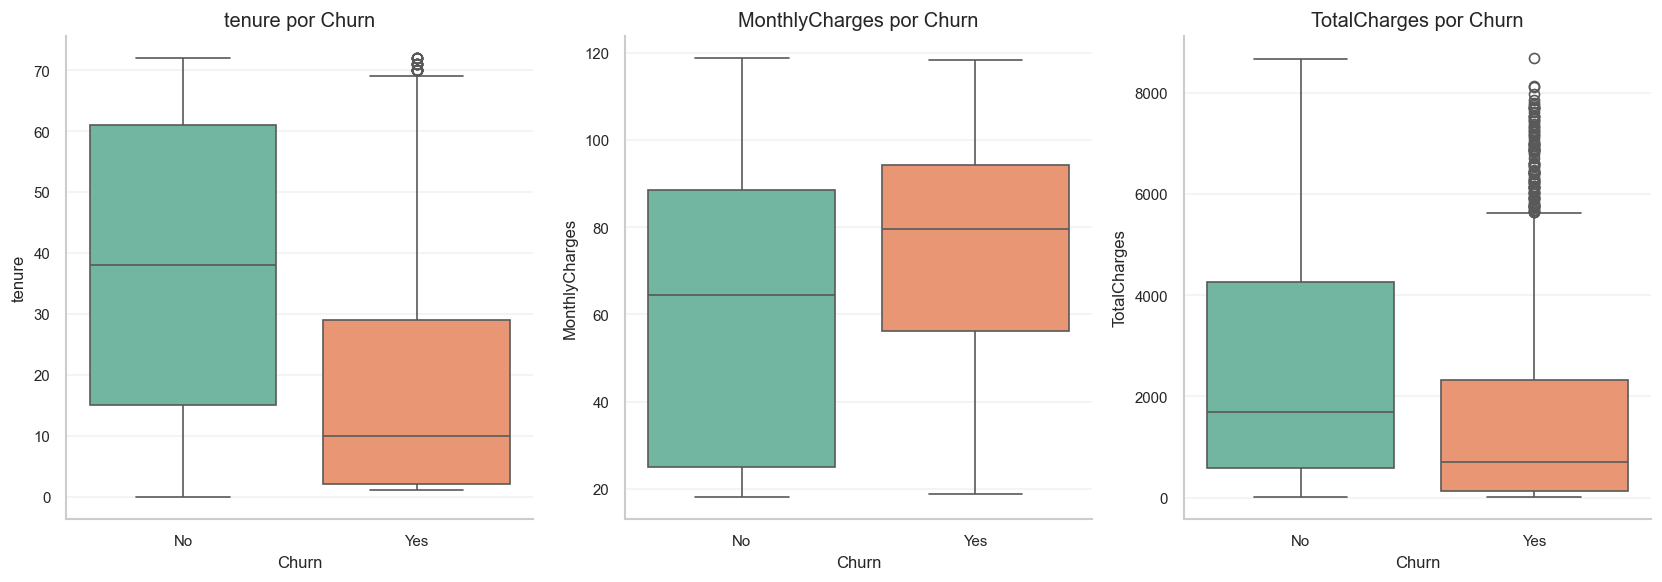

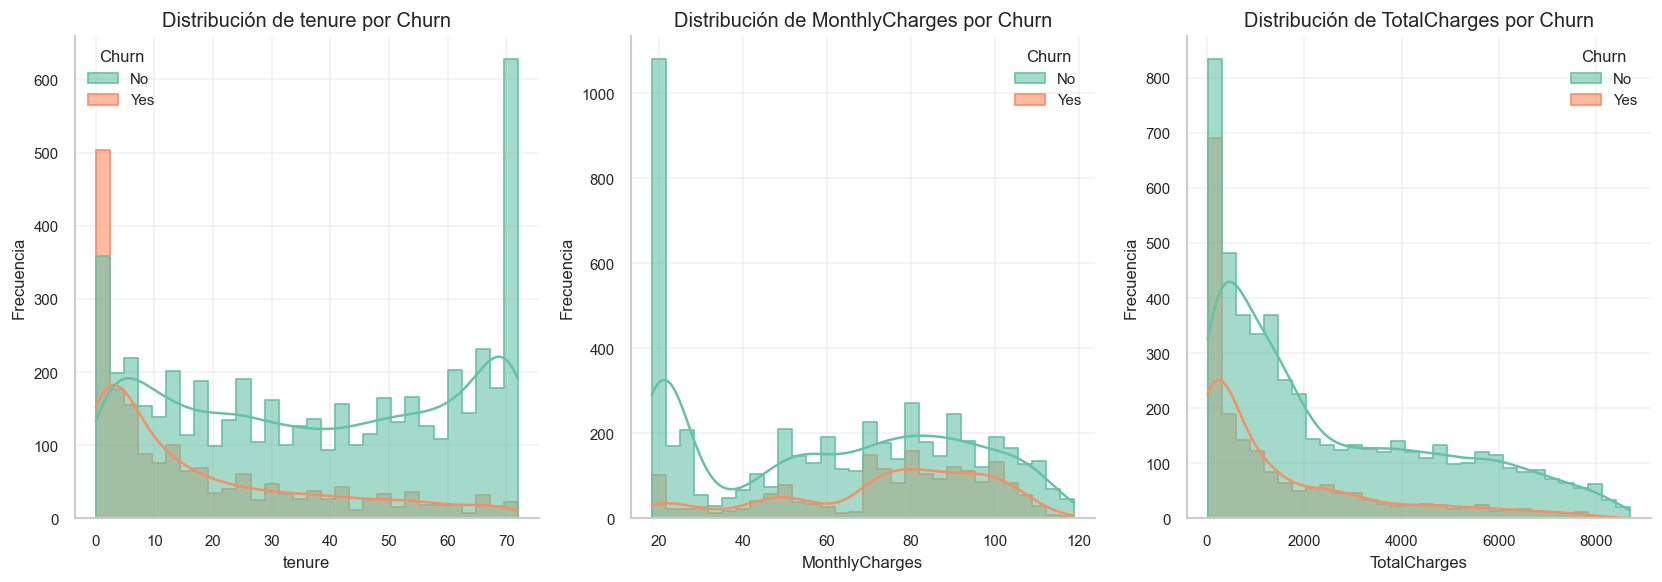

In [25]:
plt.figure(figsize=(14, 5))
for i, col in enumerate(numeric_cols, start=1):
    plt.subplot(1, 3, i)
    sns.boxplot(data=df, x='Churn', y=col, palette='Set2')
    plt.title(f'{col} por Churn')
    plt.xlabel('Churn')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
for i, col in enumerate(numeric_cols, start=1):
    plt.subplot(1, 3, i)
    sns.histplot(data=df, x=col, hue='Churn', bins=30, kde=True, element='step', alpha=0.6)
    plt.title(f'Distribución de {col} por Churn')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()


Los histogramas muestran cantidades de clientes en cada intervalo. Como hay 5174 clientes que no abandonaron y 1869 que sí lo hicieron, las diferencias de altura también reflejan el distinto tamaño de los grupos. Por eso, las barras no deben interpretarse directamente como probabilidades de abandono. La comparación se complementa con las medianas y los boxplots, que permiten observar el centro y la dispersión de cada grupo.

Los clientes que abandonaron tienen una antigüedad (tenure) mediana de 10 meses, frente a 38 meses entre quienes no abandonaron. Su cargo mensual mediano es mayor, 79.65 frente a 64.43, pero su cargo acumulado mediano es menor, 703.55 frente a 1683.60.

Estos resultados se relacionan porque una persona puede pagar más cada mes y aun así acumular un monto menor si lleva menos tiempo contratando el servicio. Las cajas también se superponen, así que ninguna de estas variables separa perfectamente ambos grupos. No puede concluirse que el cargo mensual haya causado la salida.

Entre quienes abandonaron destaca la concentración en antigüedades bajas y cargos acumulados pequeños. Entre quienes no abandonaron también aparecen muchos clientes de larga antigüedad. Los cargos mensuales muestran varias concentraciones, por lo que no conviene resumirlos únicamente con un promedio.



## 6. Análisis de variables categóricas y relaciones con churn

La mayor parte del dataset está formada por variables categóricas. Se compara el porcentaje de abandono dentro de cada categoría para identificar diferencias entre los perfiles, contratos y servicios de los clientes.

Para cada categoría se muestran el total de clientes, la cantidad de abandonos y su porcentaje. Este porcentaje se calcula respecto al total de clientes de esa categoría. La línea punteada representa el porcentaje general de abandono, de 26.54 %. Se presentan gráficas de contrato, internet, método de pago, seguridad y soporte para facilitar su comparación, mientras que las demás variables se revisan mediante tablas.

Tipo de contrato


,Clientes,Abandonos,Abandono (%)
Contract,,,
Month-to-month,3875,1655,42.71
One year,1473,166,11.27
Two year,1695,48,2.83


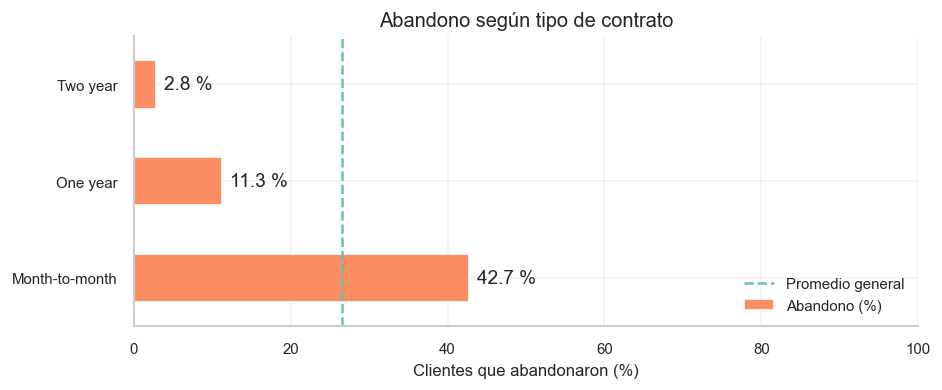

Servicio de internet


,Clientes,Abandonos,Abandono (%)
InternetService,,,
No,1526,113,7.40
DSL,2421,459,18.96
Fiber optic,3096,1297,41.89


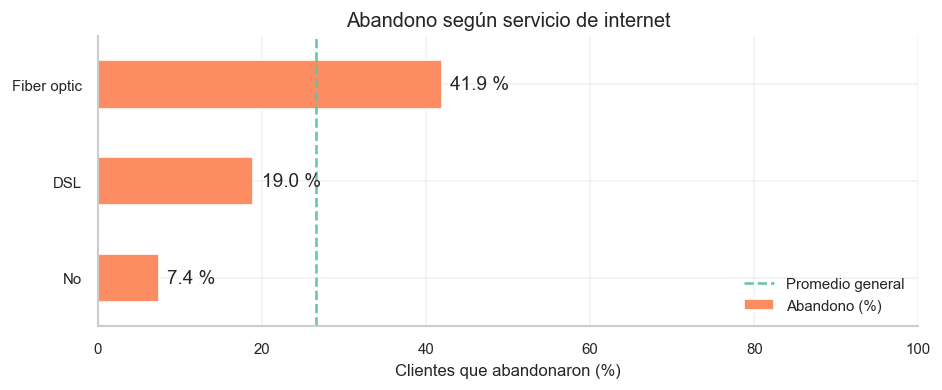

Método de pago


,Clientes,Abandonos,Abandono (%)
PaymentMethod,,,
Credit card (automatic),1522,232,15.24
Bank transfer (automatic),1544,258,16.71
Mailed check,1612,308,19.11
Electronic check,2365,1071,45.29


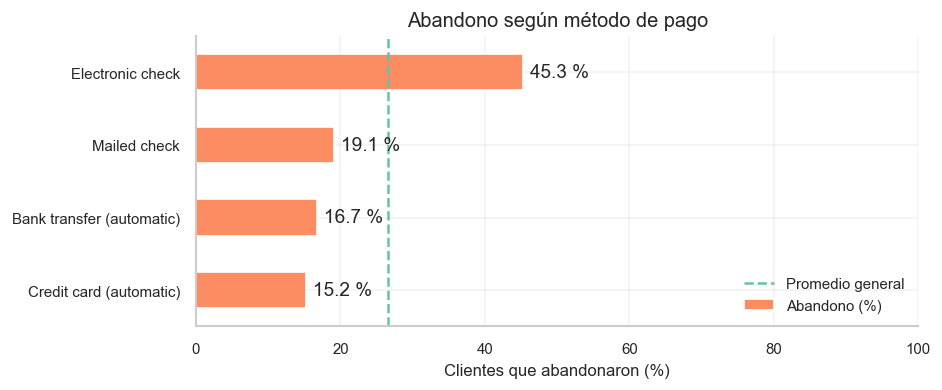

Seguridad en línea


,Clientes,Abandonos,Abandono (%)
OnlineSecurity,,,
No internet service,1526,113,7.40
Yes,2019,295,14.61
No,3498,1461,41.77


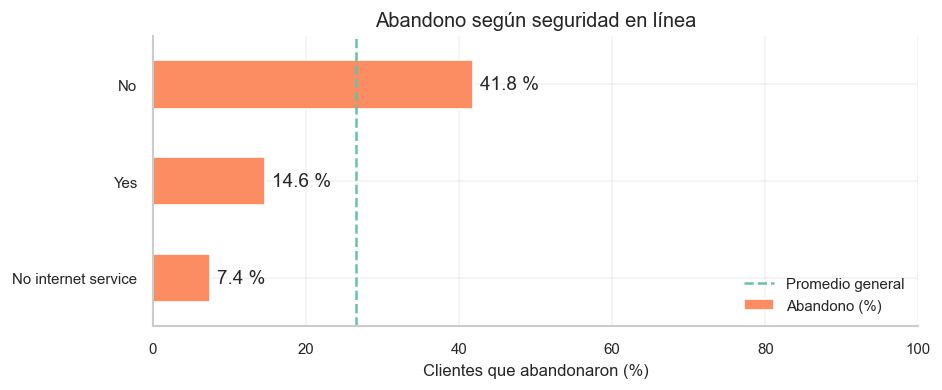

Soporte técnico


,Clientes,Abandonos,Abandono (%)
TechSupport,,,
No internet service,1526,113,7.40
Yes,2044,310,15.17
No,3473,1446,41.64


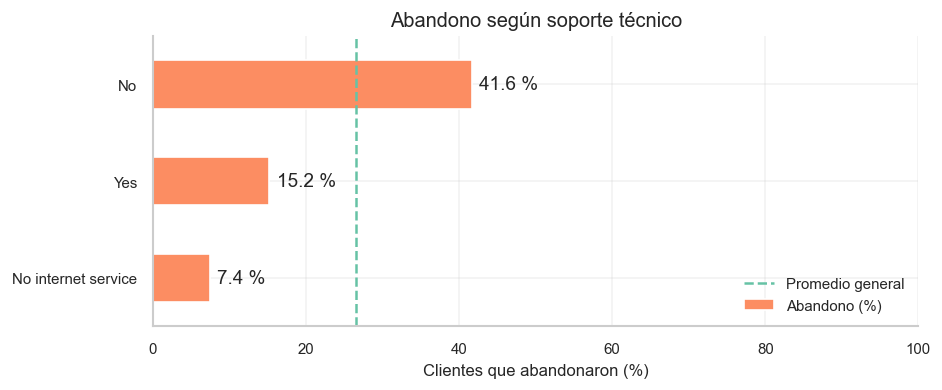

In [27]:
CONTRATOS = ["Month-to-month", "One year", "Two year"]
principales = ["Contract", "InternetService", "PaymentMethod", "OnlineSecurity", "TechSupport"]
titulos = ["Tipo de contrato", "Servicio de internet", "Método de pago",
           "Seguridad en línea", "Soporte técnico"]

for i, columna in enumerate(principales):
    tabla = df.groupby(columna)["abandono"].agg(["count", "sum", "mean"])
    tabla.columns = ["Clientes", "Abandonos", "Abandono (%)"]
    tabla["Abandono (%)"] = tabla["Abandono (%)"] * 100
    if columna == "Contract":
        tabla = tabla.reindex(CONTRATOS)
    else:
        tabla = tabla.sort_values("Abandono (%)")
    print(titulos[i])
    display(tabla.round(2))
    ax = tabla["Abandono (%)"].plot.barh(color=COLORES["Yes"], figsize=(8, 3.4))
    ax.axvline(tasa_global, color=COLORES["No"], linestyle="--", label="Promedio general")
    ax.set_xlim(0, 100)
    ax.set_title("Abandono según " + titulos[i].lower())
    ax.set_xlabel("Clientes que abandonaron (%)")
    ax.set_ylabel("")
    for j, valor in enumerate(tabla["Abandono (%)"]):
        ax.text(valor + 1, j, f"{valor:.1f} %", va="center")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

**1. Contrato.** El abandono es 42.7 % en contratos mensuales, 11.3 % en contratos de un año y 2.8 % en contratos de dos años. La diferencia entre los extremos es de aproximadamente 39.9 puntos porcentuales. Es una asociación clara en esta muestra, pero los grupos podrían diferir también en antigüedad y servicios.

**2. Internet.** Fibra óptica presenta 41.9 % de abandono, DSL 19.0 % y el grupo sin internet 7.4 %. Esto no demuestra una mala calidad de la fibra: no se midieron fallas, satisfacción ni motivos de salida. Más adelante se compara internet dentro de cada contrato.

**3. Pago.** Electronic check presenta 45.3 %, frente a aproximadamente 15–19 % en los otros métodos. El método podría estar relacionado con el perfil o contrato de los clientes; cambiarlo no garantiza reducir abandonos.

**4. Complementos.** La seguridad en línea y el soporte técnico muestran menores porcentajes entre quienes los tienen. Sin embargo, la categoría sin internet reaparece en ambos gráficos y corresponde al mismo grupo de clientes. No debe interpretarse como evidencia independiente repetida.


In [30]:
for columna in categoricas:
    if columna not in principales + ["customerID"] :
        tabla = df.groupby(columna)["abandono"].agg(["count", "sum", "mean"])
        tabla.columns = ["Clientes", "Abandonos", "Abandono (%)"]
        tabla["Abandono (%)"] = tabla["Abandono (%)"] * 100
        print("\n", columna)
        display(tabla.round(2))



 gender


,Clientes,Abandonos,Abandono (%)
gender,,,
Female,3488,939,26.92
Male,3555,930,26.16



 SeniorCitizen


,Clientes,Abandonos,Abandono (%)
SeniorCitizen,,,
0,5901,1393,23.61
1,1142,476,41.68



 Partner


...

,Clientes,Abandonos,Abandono (%)
StreamingTV,,,
No,2810,942,33.52
No internet service,1526,113,7.40
Yes,2707,814,30.07



 StreamingMovies


,Clientes,Abandonos,Abandono (%)
StreamingMovies,,,
No,2785,938,33.68
No internet service,1526,113,7.40
Yes,2732,818,29.94



 PaperlessBilling


,Clientes,Abandonos,Abandono (%)
PaperlessBilling,,,
No,2872,469,16.33
Yes,4171,1400,33.57


En género, los porcentajes son parecidos: 26.9 % en Female y 26.2 % en Male. Tampoco se observa una diferencia grande según servicio telefónico: 24.9 % sin ese servicio y 26.7 % con él. Estas variables muestran poca separación al analizarlas individualmente, aunque eso no obliga a descartarlas antes de evaluar modelos.

En cambio, SeniorCitizen = 1 presenta 41.7 % frente a 23.6 % en la otra categoría; sin pareja se observa 33.0 % frente a 19.7 % con pareja; y sin dependientes, 31.3 % frente a 15.5 % con dependientes. La facturación sin papel también muestra una diferencia: 33.6 % frente a 16.3 %.

Los servicios adicionales no muestran diferencias de la misma magnitud. En respaldo en línea, el abandono es de 39.9 % entre quienes no tienen el complemento y de 21.5 % entre quienes sí lo tienen. En protección del dispositivo, los porcentajes son 39.1 % y 22.5 %, respectivamente. En cambio, las diferencias son menores para streaming de televisión, con 33.5 % frente a 30.1 %, y de películas, con 33.7 % frente a 29.9 %. Estas comparaciones consideran las categorías Yes y No, sin incluir al grupo que no tiene internet. Por tanto, no conviene tratar todos los complementos como si presentaran la misma relación con el abandono.

Estos resultados describen grupos, no explican las decisiones de cada persona. Una diferencia por edad tampoco demuestra por sí sola sesgo del dataset o del futuro modelo. Para estudiar ese punto se necesitaría revisar representatividad y errores del modelo entre grupos.


## 7. Antigüedad y contrato: comparación conjunta

Se agrupa la antigüedad en los intervalos de 0–12, 13–24, 25–48 y 49–72 meses para distinguir clientes con hasta un año de permanencia, entre uno y dos años, entre dos y cuatro años y más de cuatro años. Estos cortes se eligieron para facilitar la comparación y no representan límites óptimos determinados por un modelo. Aunque los intervalos tienen distinta amplitud, se compara el porcentaje de abandono dentro de cada combinación de antigüedad y contrato, acompañado de su cantidad de clientes. La variable de antigüedad original se conserva sin modificar.


,Clientes,Abandono (%)
grupo_antiguedad,,
0–12,2186,47.44
13–24,1024,28.71
25–48,1594,20.39
49–72,2239,9.51


Cantidad de clientes por combinación:


Contract,Month-to-month,One year,Two year
grupo_antiguedad,,,
0–12,1994,124,68
13–24,737,197,90
25–48,802,518,274
49–72,342,634,1263


Porcentaje de abandono por combinación:


Contract,Month-to-month,One year,Two year
grupo_antiguedad,,,
0–12,51.35,10.48,0.00
13–24,37.72,8.12,0.00
25–48,32.92,10.62,2.19
49–72,26.02,12.93,3.33


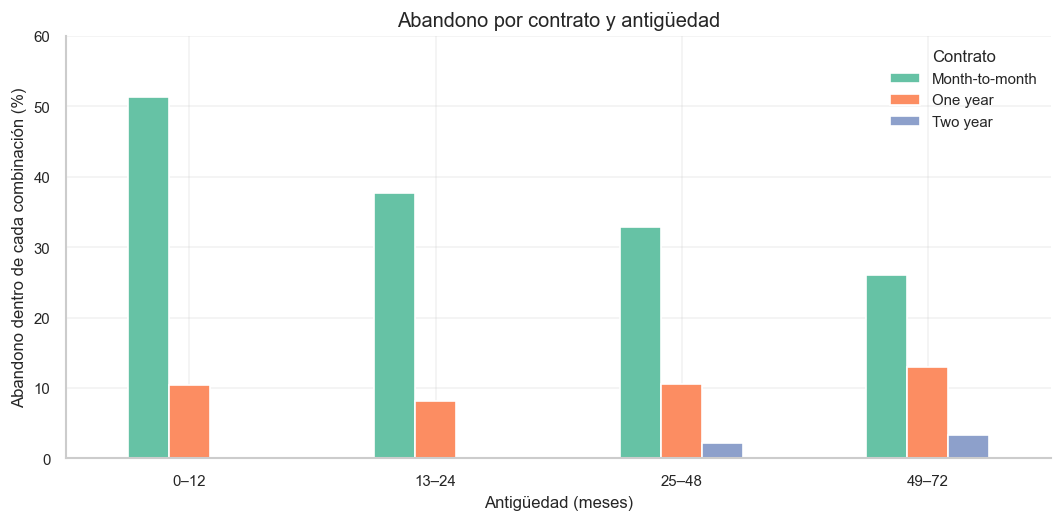

In [33]:
df["grupo_antiguedad"] = pd.cut(
    df["tenure"], bins=[-1, 12, 24, 48, 72],
    labels=["0–12", "13–24", "25–48", "49–72"]
)
por_tiempo = df.groupby("grupo_antiguedad", observed=True)["abandono"].agg(["count", "mean"])
por_tiempo.columns = ["Clientes", "Abandono (%)"]
por_tiempo["Abandono (%)"] *= 100
display(por_tiempo.round(2))

cantidad = pd.crosstab(df["grupo_antiguedad"], df["Contract"]).reindex(columns=CONTRATOS)
tasas = df.pivot_table(index="grupo_antiguedad", columns="Contract",
                       values="abandono", aggfunc="mean", observed=True) * 100
tasas = tasas.reindex(columns=CONTRATOS)
print("Cantidad de clientes por combinación:")
display(cantidad)
print("Porcentaje de abandono por combinación:")
display(tasas.round(2))

ax = tasas.plot.bar(figsize=(9, 4.5), color=[paleta[0], paleta[1], paleta[2]], rot=0)
ax.set_title("Abandono por contrato y antigüedad")
ax.set_xlabel("Antigüedad (meses)")
ax.set_ylabel("Abandono dentro de cada combinación (%)")
ax.set_ylim(0, 60)
ax.legend(title="Contrato")
plt.tight_layout()
plt.show()


La diferencia entre contratos se mantiene dentro de estos grupos de antigüedad. Entre clientes de 0–12 meses, abandonó el 51.4 % de quienes tenían contrato mensual, frente al 10.5 % de quienes tenían contrato anual. Entre clientes de 49–72 meses, los porcentajes son 26.0 %, 12.9 % y 3.3 % para contratos mensuales, anuales y de dos años, respectivamente.

Esto sugiere que la diferencia global entre contratos no se explica únicamente por estos intervalos de antigüedad. Aun así, los intervalos son amplios y quedan otras características sin comparar.

Los grupos no tienen el mismo tamaño: en 0–12 meses hay 1994 contratos mensuales, 124 anuales y solo 68 de dos años. En este último grupo no se observaron abandonos; eso no significa que su probabilidad real sea cero. Tampoco puede interpretarse que esperar más meses reduciría por sí mismo el riesgo.


## 8. Servicio de internet dentro de cada contrato
Se compara DSL, fibra óptica y ausencia de internet dentro de cada tipo de contrato, para revisar si la asociación global permanece.

InternetService,DSL,Fiber optic,No
Contract,,,
Month-to-month,1223,2128,524
One year,570,539,364
Two year,628,429,638


InternetService,DSL,Fiber optic,No
Contract,,,
Month-to-month,32.22,54.61,18.89
One year,9.30,19.29,2.47
Two year,1.91,7.23,0.78


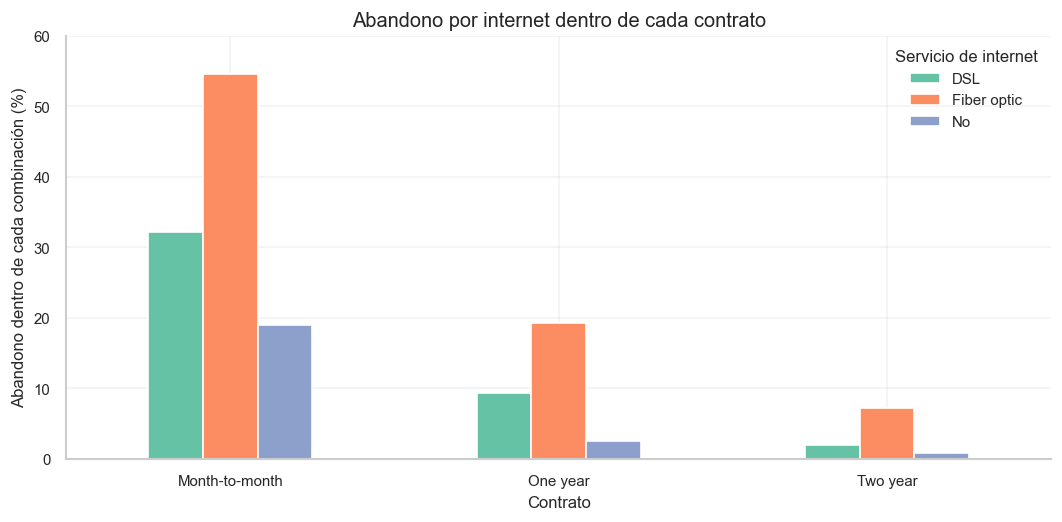

In [35]:
cantidad_internet = pd.crosstab(df["Contract"], df["InternetService"]).reindex(CONTRATOS)
tasas_internet = df.pivot_table(index="Contract", columns="InternetService",
                                values="abandono", aggfunc="mean") * 100
tasas_internet = tasas_internet.reindex(CONTRATOS)
display(cantidad_internet)
display(tasas_internet.round(2))

ax = tasas_internet.plot.bar(figsize=(9, 4.5), color=[paleta[0], paleta[1], paleta[2]], rot=0)
ax.set_title("Abandono por internet dentro de cada contrato")
ax.set_xlabel("Contrato")
ax.set_ylabel("Abandono dentro de cada combinación (%)")
ax.set_ylim(0, 60)
ax.legend(title="Servicio de internet")
plt.tight_layout()
plt.show()


La fibra presenta mayor abandono que DSL dentro de cada tipo de contrato: 54.6 % frente a 32.2 % en contratos mensuales, 19.3 % frente a 9.3 % en anuales y 7.2 % frente a 1.9 % en contratos de dos años.

Por tanto, la diferencia observada no desaparece al separar por contrato. Sin embargo, todavía pueden diferir los cargos, la antigüedad u otras características dentro de cada grupo. No se puede atribuir la diferencia a la tecnología de internet ni concluir que la fibra sea de peor calidad.


## 9. Valores atípicos: criterio global y por grupo
Se usa la regla de 1.5 × IQR para señalar valores alejados de la parte central de cada distribución. Es un criterio de revisión, no una prueba de error.


In [37]:
for columna in numeric_cols:
    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)
    iqr = q3 - q1
    inferior = q1 - 1.5 * iqr
    superior = q3 + 1.5 * iqr
    atipicos = (df[columna] < inferior) | (df[columna] > superior)
    print(columna, ":", atipicos.sum(), "atípicos globales; límites:",
          round(inferior, 2), "a", round(superior, 2))

print("\nRevisión dentro de cada grupo de abandono:")
for estado in ORDEN:
    grupo = df[df["Churn"] == estado]
    for columna in numeric_cols:
        q1 = grupo[columna].quantile(0.25)
        q3 = grupo[columna].quantile(0.75)
        iqr = q3 - q1
        atipicos = (grupo[columna] < q1 - 1.5 * iqr) | (grupo[columna] > q3 + 1.5 * iqr)
        print(estado, columna, ":", atipicos.sum())


tenure : 0 atípicos globales; límites: -60.0 a 124.0
MonthlyCharges : 0 atípicos globales; límites: -46.02 a 171.38
TotalCharges : 0 atípicos globales; límites: -4688.48 a 8884.67

Revisión dentro de cada grupo de abandono:
No tenure : 0
No MonthlyCharges : 0
No TotalCharges : 0
Yes tenure : 23
Yes MonthlyCharges : 0
Yes TotalCharges : 109


La regla IQR aplicada a toda la base no señala valores atípicos en ninguna de las tres variables. Sin embargo, al aplicarla por separado entre quienes abandonaron, se identifican 23 valores atípicos de antigüedad y 109 de cargo acumulado. Esto ocurre porque cada grupo tiene sus propios cuartiles y límites. Los conteos corresponden a cada variable y no deben sumarse como si representaran clientes distintos, ya que una misma persona podría aparecer en ambos.

Un cargo acumulado alto puede ser poco habitual entre quienes abandonaron, aunque no lo sea en la base completa. Además, los límites inferiores globales son negativos, lo que muestra que la regla IQR no sustituye la revisión de valores imposibles. Se conservan los valores observados porque estar fuera de esos límites no demuestra que sean incorrectos.

## 10. Relaciones numéricas y preparación para el modelo

La correlación de Pearson permite resumir asociaciones lineales entre la antigüedad, el cargo mensual y el cargo acumulado. Las variables categóricas se analizaron mediante comparaciones de porcentajes en las secciones anteriores. Para cada correlación se utilizan los clientes que tienen información en ambas variables. Por eso, las comparaciones que incluyen TotalCharges consideran 7032 clientes, mientras que la comparación entre antigüedad y cargo mensual utiliza los 7043.


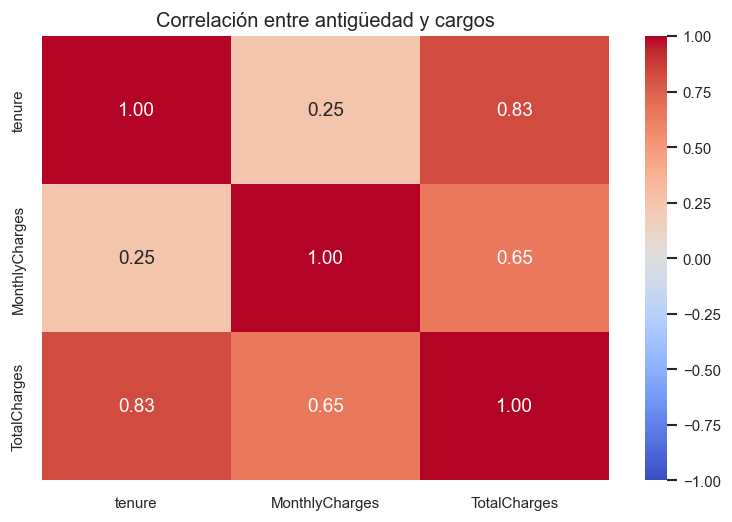

,tenure,MonthlyCharges,TotalCharges
tenure,1.000,0.248,0.826
MonthlyCharges,0.248,1.000,0.651
TotalCharges,0.826,0.651,1.000


In [40]:
correlacion = df[numeric_cols].corr()
plt.figure(figsize=(6.5, 4.5))
sns.heatmap(correlacion, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlación entre antigüedad y cargos")
plt.tight_layout()
plt.show()
display(correlacion.round(3))

TotalCharges se relaciona fuertemente con tenure (r = 0.826) y también con el cargo mensual (r = 0.651). La asociación entre tenure y cargo mensual es menor (r = 0.248). Esto es coherente con la interpretación del acumulado: depende del tiempo y de lo pagado durante ese periodo, aunque no necesariamente equivale al cargo mensual actual multiplicado por los meses.

Estas relaciones pueden generar información redundante, pero no justifican eliminar automáticamente TotalCharges. Tampoco constituyen por sí mismas una fuga de información. Habría fuga si se utilizara información que no estuviera disponible al momento en que se quiere predecir.

Los complementos también dependen del acceso a internet, como muestran las comprobaciones de coherencia. No se ha cuantificado una asociación fuerte de todos ellos con el contrato, por lo que no se afirma que esa relación esté demostrada.

## 11. Conclusiones y siguientes pasos

1. **Calidad.** La base contiene 7043 clientes, sin duplicados ni inconsistencias en las comprobaciones aplicadas. Hay 11 cargos acumulados faltantes, todos con antigüedad cero. Se conservan los registros y se deja explícito que los análisis de ese cargo usan 7032 observaciones.
2. **Balance.** El 26.54 % de los clientes abandonó. Predecir siempre que un cliente no abandonará daría 73.46 % de acierto, pero no identificaría ninguna salida. Por eso, el futuro modelo debe compararse con esa referencia considerando también cuántos abandonos detecta y cuántas falsas alertas genera. Un mayor porcentaje de aciertos no garantiza por sí solo un modelo más útil.
3. **Contrato y antigüedad.** Los contratos mensuales presentan mayor abandono. La diferencia se mantiene dentro de intervalos de antigüedad, aunque los tamaños de grupo varían y las comparaciones no prueban causalidad.
4. **Internet y complementos.** Fibra óptica presenta mayor abandono que DSL incluso al separar por contrato. Seguridad y soporte se asocian con menores porcentajes entre clientes con internet, sin demostrar un efecto protector por sí solos.
5. **Cargos.** Quienes abandonaron tienen mayor cargo mensual mediano, pero menor antigüedad y cargo acumulado. Las tres variables deben interpretarse juntas.
6. **Límites.** No hay seguimiento temporal individual, motivos de salida ni evaluación de representatividad. Las diferencias observadas no deben generalizarse a todas las empresas o interpretarse como causas.

**Para la etapa de modelado:**
- Definir el momento de predicción y comprobar qué variables estarían disponibles entonces. Este EDA no valida un horizonte futuro específico.
- Separar entrenamiento y prueba manteniendo la proporción de clases. Si se usa esta base ya explorada, reconocer que la prueba no quedó totalmente ajena al EDA; evitar ajustar decisiones con sus resultados y, si es posible, reservar datos nuevos para validación final.
- Excluir `customerID`, `Churn` y la columna auxiliar `abandono` de las entradas. `Churn` o `abandono` se utiliza exclusivamente como objetivo. Conservar inicialmente `tenure` original y omitir `grupo_antiguedad`, creado solo para estas comparaciones.
- Ajustar imputación y codificación únicamente con entrenamiento; escalar si el modelo lo requiere. Mantener claras las categorías de ausencia de internet y de complemento.
- Empezar con una referencia mayoritaria y una regresión logística; después comparar con un árbol u otro modelo del curso. No hace falta comenzar con modelos complejos ni aplicar balanceo automáticamente.
- Reportar matriz de confusión, precisión, recall y F1 para abandono, junto con una métrica de ranking como PR-AUC. Elegir el umbral con validación considerando el costo de no detectar una salida y el de generar una falsa alerta.